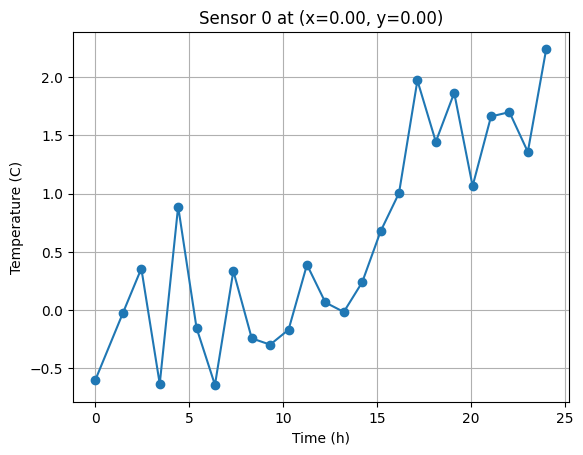

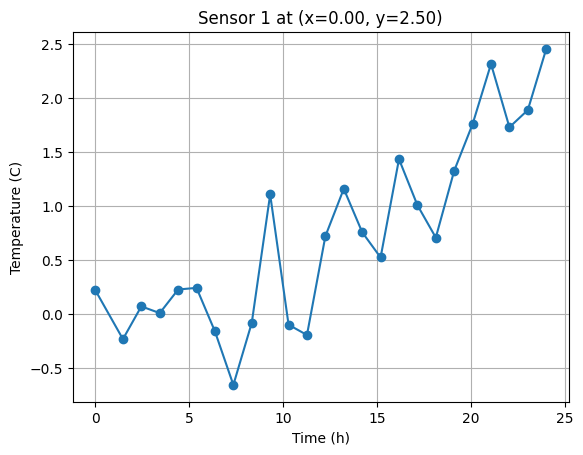

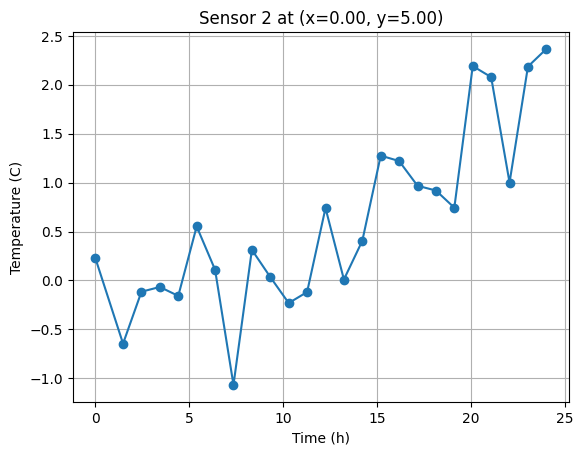

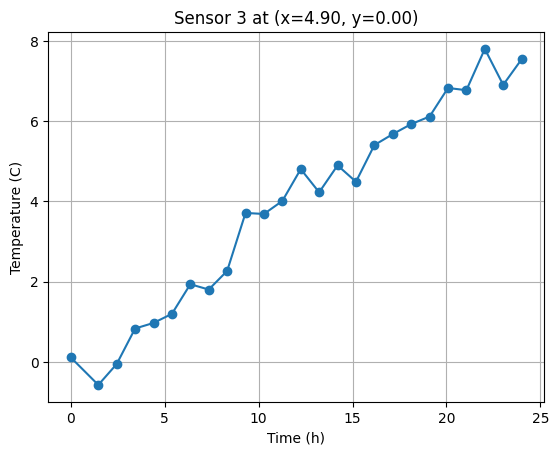

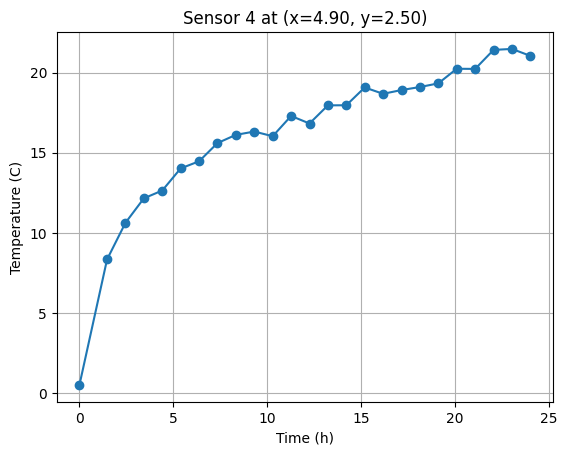

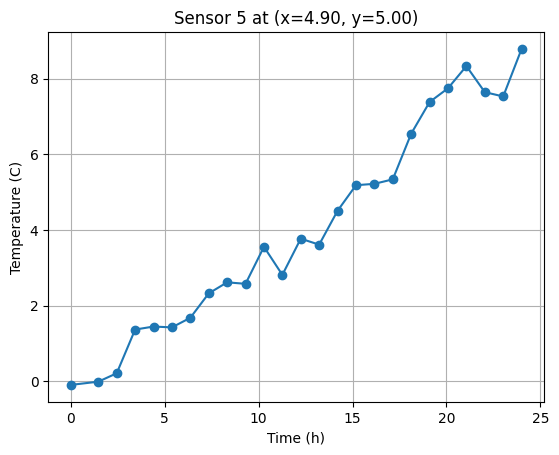

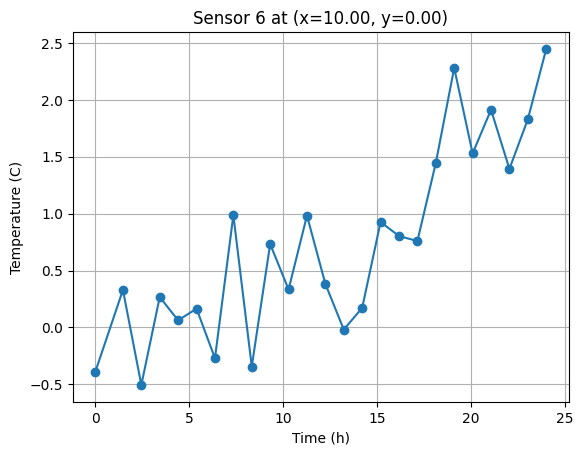

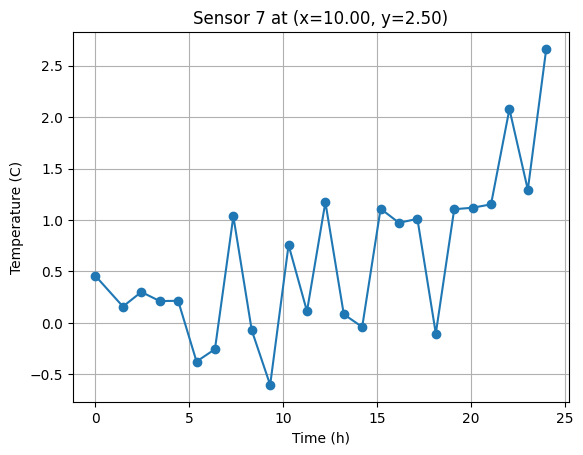

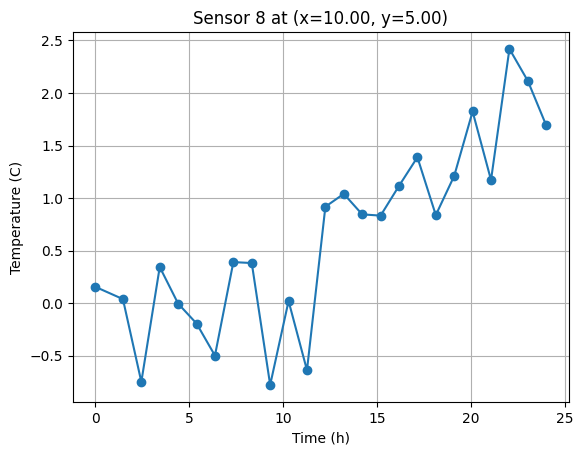

In [22]:
from project.config import load_config
from project.data import generate_training_data
import matplotlib.pyplot as plt
import numpy as np

cfg = load_config("../../config.yaml")
x, y, t, T_fdm, sensor_data = generate_training_data(cfg)

sd = np.asarray(sensor_data)

x_s = sd[:, 0]
y_s = sd[:, 1]
time_s = sd[:, 2]
T_s = sd[:, 3]

positions = np.unique(sd[:, :2], axis=0)

for i, (sx, sy) in enumerate(positions):
    mask = np.isclose(x_s, sx) & np.isclose(y_s, sy)
    idx = np.argsort(time_s[mask])

    plt.figure()
    plt.plot(time_s[mask][idx], T_s[mask][idx], "o-")
    plt.title(f"Sensor {i} at (x={sx:.2f}, y={sy:.2f})")
    plt.xlabel("Time (h)")
    plt.ylabel("Temperature (C)")
    plt.grid(True)
    plt.show()
